# Thống kê tổng quan, tiền xử lý và EDA dữ liệu NASA POWER Việt Nam

Notebook này phân tích file **`nasa_power_vietnam_daily.csv`** ở cấp độ **một địa điểm × một ngày**, gồm **20 điểm tham chiếu được phân vào 6 nhóm vùng phân tích**.

**Mục tiêu**

1. Kiểm tra cấu trúc, phạm vi thời gian và mức độ đầy đủ của dữ liệu.
2. Làm sạch kiểu dữ liệu, giá trị sentinel, bản ghi trùng và các biến thời gian.
3. Kiểm định tính nhất quán của các biến dẫn xuất/cờ cực đoan.
4. EDA nhiệt độ, lượng mưa, độ ẩm, xu hướng theo tháng/năm/vùng và heatwave.
5. So sánh đặc điểm khí hậu giữa 6 nhóm vùng sau khi ánh xạ lại 20 điểm tham chiếu.

> **Lưu ý phương pháp:** bộ dữ liệu gồm các **điểm/grid tham chiếu**, không đại diện cho trung bình diện tích của toàn bộ tỉnh, vùng hay Việt Nam. Các tổng hợp toàn bộ dữ liệu trong notebook dùng trọng số bằng nhau cho từng địa điểm.

## 1. Cài đặt và import thư viện

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 2.2.3
NumPy: 2.3.5


## 2. Xác định đường dẫn và đọc dữ liệu

In [ ]:
# Notebook chạy được cả trên Google Colab và môi trường hiện tại.
# Trên Colab: hãy upload file CSV vào /content trước khi chạy.

preferred_names = [
    "nasa_power_vietnam_daily.csv"
]
search_dirs = [Path("/content"), Path("/mnt/data"), Path.cwd()]

DATA_PATH = None
for folder in search_dirs:
    for filename in preferred_names:
        candidate = folder / filename
        if candidate.exists():
            DATA_PATH = candidate
            break
    if DATA_PATH is not None:
        break

if DATA_PATH is None:
    try:
        from google.colab import files
        print("Không tìm thấy CSV. Hãy chọn file để upload lên Colab.")
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except Exception as exc:
        raise FileNotFoundError(
            "Không tìm thấy file CSV. Hãy upload nasa_power_vietnam_daily.csv."
        ) from exc

print("Đang đọc:", DATA_PATH)
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig", low_memory=False)
print(f"Kích thước dữ liệu: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"Dung lượng DataFrame ban đầu: {df_raw.memory_usage(deep=True).sum() / 1024**2:,.2f} MB")

Đang đọc: /mnt/data/nasa_power_vietnam_daily.csv


Kích thước dữ liệu: 255,680 dòng × 36 cột
Dung lượng DataFrame ban đầu: 165.47 MB


In [ ]:
# Ánh xạ 20 điểm tham chiếu vào 6 nhóm vùng phân tích.
location_to_region = {
    # 1. Trung du và miền núi phía Bắc
    "Lao Cai": "Trung du và miền núi phía Bắc",
    "Dien Bien Phu": "Trung du và miền núi phía Bắc",

    # 2. Đồng bằng sông Hồng
    "Ha Noi": "Đồng bằng sông Hồng",
    "Hai Phong": "Đồng bằng sông Hồng",

    # 3. Bắc Trung Bộ
    "Dong Hoi": "Bắc Trung Bộ",
    "Vinh": "Bắc Trung Bộ",
    "Hue": "Bắc Trung Bộ",

    # 4. Nam Trung Bộ (nhóm phân tích gồm cả các điểm Tây Nguyên trong bộ dữ liệu)
    "Da Nang": "Nam Trung Bộ",
    "Nha Trang": "Nam Trung Bộ",
    "Phan Rang-Thap Cham": "Nam Trung Bộ",
    "Quy Nhon": "Nam Trung Bộ",
    "Buon Ma Thuot": "Nam Trung Bộ",
    "Da Lat": "Nam Trung Bộ",
    "Pleiku": "Nam Trung Bộ",

    # 5. Đông Nam Bộ
    "Ho Chi Minh City": "Đông Nam Bộ",
    "Vung Tau": "Đông Nam Bộ",

    # 6. Đồng bằng sông Cửu Long
    "Ca Mau": "Đồng bằng sông Cửu Long",
    "Chau Doc": "Đồng bằng sông Cửu Long",
    "Phu Quoc": "Đồng bằng sông Cửu Long",
    "Can Tho": "Đồng bằng sông Cửu Long",
}

region_order = [
    "Trung du và miền núi phía Bắc",
    "Đồng bằng sông Hồng",
    "Bắc Trung Bộ",
    "Nam Trung Bộ",
    "Đông Nam Bộ",
    "Đồng bằng sông Cửu Long",
]

unmapped_locations = sorted(
    set(df_raw["location_name"].dropna().unique()) - set(location_to_region)
)
if unmapped_locations:
    raise ValueError(f"Các địa điểm chưa được ánh xạ vùng: {unmapped_locations}")

df_raw["region"] = pd.Categorical(
    df_raw["location_name"].map(location_to_region),
    categories=region_order,
    ordered=True,
)

print(f"Số nhóm vùng sau ánh xạ: {df_raw['region'].nunique()}")
df_raw["region"].unique()

Số nhóm vùng sau ánh xạ: 6


['Nam Trung Bộ', 'Đồng bằng sông Cửu Long', 'Trung du và miền núi phía Bắc', 'Đồng bằng sông Hồng', 'Bắc Trung Bộ', 'Đông Nam Bộ']
Categories (6, object): ['Trung du và miền núi phía Bắc' < 'Đồng bằng sông Hồng' < 'Bắc Trung Bộ' < 'Nam Trung Bộ' < 'Đông Nam Bộ' < 'Đồng bằng sông Cửu Long']

In [ ]:
df_raw['location_name'].unique()

array(['Buon Ma Thuot', 'Ca Mau', 'Chau Doc', 'Nha Trang', 'Da Nang',
       'Dien Bien Phu', 'Da Lat', 'Ha Noi', 'Hai Phong', 'Hue', 'Lao Cai',
       'Phu Quoc', 'Phan Rang-Thap Cham', 'Pleiku', 'Ho Chi Minh City',
       'Quy Nhon', 'Can Tho', 'Dong Hoi', 'Vinh', 'Vung Tau'],
      dtype=object)

In [ ]:
locations_by_region = (
    df_raw.groupby("region", observed=True, sort=True)["location_name"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

locations_by_region

{'Trung du và miền núi phía Bắc': ['Dien Bien Phu', 'Lao Cai'],
 'Đồng bằng sông Hồng': ['Ha Noi', 'Hai Phong'],
 'Bắc Trung Bộ': ['Dong Hoi', 'Hue', 'Vinh'],
 'Nam Trung Bộ': ['Buon Ma Thuot',
  'Da Lat',
  'Da Nang',
  'Nha Trang',
  'Phan Rang-Thap Cham',
  'Pleiku',
  'Quy Nhon'],
 'Đông Nam Bộ': ['Ho Chi Minh City', 'Vung Tau'],
 'Đồng bằng sông Cửu Long': ['Ca Mau', 'Can Tho', 'Chau Doc', 'Phu Quoc']}

In [ ]:
for region, locations in locations_by_region.items():
    print(f"\n{region}:")

    for location in locations:
        print(f"  - {location}")


Trung du và miền núi phía Bắc:
  - Dien Bien Phu
  - Lao Cai

Đồng bằng sông Hồng:
  - Ha Noi
  - Hai Phong

Bắc Trung Bộ:
  - Dong Hoi
  - Hue
  - Vinh

Nam Trung Bộ:
  - Buon Ma Thuot
  - Da Lat
  - Da Nang
  - Nha Trang
  - Phan Rang-Thap Cham
  - Pleiku
  - Quy Nhon

Đông Nam Bộ:
  - Ho Chi Minh City
  - Vung Tau

Đồng bằng sông Cửu Long:
  - Ca Mau
  - Can Tho
  - Chau Doc
  - Phu Quoc


In [ ]:
display(df_raw.head())

,date,location_id,location_name,region,latitude,longitude,T2M,T2M_MAX,T2M_MIN,T2MDEW,RH2M,QV2M,PRECTOTCORR,WS10M,PS,ALLSKY_SFC_SW_DWN,source,retrieved_at_utc,year,month,month_name,quarter,temperature_range,hot_day,very_hot_day,heavy_rain_day,dry_day,T2M_7d_rolling_mean,T2M_30d_rolling_mean,hot_run_length,dry_run_length,heatwave_day,heatwave_event_start,heatwave_event_end,heatwave_event_id,heatwave_event_length
0,1991-01-01,BMV,Buon Ma Thuot,Nam Trung Bộ,12.667,108.050,22.270,28.210,17.690,18.240,79.870,13.970,0.000,1.690,94.130,19.640,NASA POWER,2026-07-12T10:30:26.289007+00:00,1991,1,Jan,1,10.520,0,0,0,1,NaN,NaN,0,1,0,0,0,NaN,0
1,1991-01-02,BMV,Buon Ma Thuot,Nam Trung Bộ,12.667,108.050,21.940,27.340,18.490,17.770,79.010,13.540,0.020,2.120,94.180,19.520,NASA POWER,2026-07-12T10:30:26.289007+00:00,1991,1,Jan,1,8.850,0,0,0,1,NaN,NaN,0,2,0,0,0,NaN,0
2,1991-01-03,BMV,Buon Ma Thuot,Nam Trung Bộ,12.667,108.050,22.120,27.770,18.420,17.950,79.110,13.690,0.440,2.300,94.240,16.020,NASA POWER,2026-07-12T10:30:26.289007+00:00,1991,1,Jan,1,9.350,0,0,0,1,NaN,NaN,0,3,0,0,0,NaN,0
3,1991-01-04,BMV,Buon Ma Thuot,Nam Trung Bộ,12.667,108.050,22.570,28.200,18.780,18.400,79.290,14.100,0.210,1.970,94.190,17.100,NASA POWER,2026-07-12T10:30:26.289007+00:00,1991,1,Jan,1,9.420,0,0,0,1,22.225,NaN,0,4,0,0,0,NaN,0
4,1991-01-05,BMV,Buon Ma Thuot,Nam Trung Bộ,12.667,108.050,22.540,28.300,18.230,18.010,77.530,13.750,0.400,2.160,94.180,18.200,NASA POWER,2026-07-12T10:30:26.289007+00:00,1991,1,Jan,1,10.070,0,0,0,1,22.288,NaN,0,5,0,0,0,NaN,0


## 3. Thống kê tổng quan dữ liệu

In [ ]:
dtype_overview = (
    pd.DataFrame({
        "column": df_raw.columns,
        "dtype": df_raw.dtypes.astype(str).values,
        "non_null": df_raw.notna().sum().values,
        "missing": df_raw.isna().sum().values,
        "missing_pct": (df_raw.isna().mean().values * 100),
        "n_unique": [df_raw[c].nunique(dropna=True) for c in df_raw.columns],
    })
    .sort_values(["missing", "column"], ascending=[False, True])
    .reset_index(drop=True)
)
display(dtype_overview)

,column,dtype,non_null,missing,missing_pct,n_unique
0,heatwave_event_id,object,12159,243521,95.244,1368
1,T2M_30d_rolling_mean,float64,255400,280,0.110,63186
2,T2M_7d_rolling_mean,float64,255620,60,0.023,24717
3,ALLSKY_SFC_SW_DWN,float64,255680,0,0.000,2704
4,PRECTOTCORR,float64,255680,0,0.000,6646
5,PS,float64,255680,0,0.000,1136
6,QV2M,float64,255680,0,0.000,1965
7,RH2M,float64,255680,0,0.000,5281
8,T2M,float64,255680,0,0.000,2880
9,T2MDEW,float64,255680,0,0.000,2691


In [ ]:
# Chuyển tạm date sang datetime để thống kê phạm vi trước tiền xử lý chính thức.
date_temp = pd.to_datetime(df_raw["date"], errors="coerce")

coverage = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng", "Số cột", "Ngày bắt đầu", "Ngày kết thúc",
        "Số năm", "Số địa điểm", "Số vùng", "Số nguồn dữ liệu"
    ],
    "Giá trị": [
        f"{len(df_raw):,}",
        df_raw.shape[1],
        date_temp.min().date(),
        date_temp.max().date(),
        date_temp.dt.year.nunique(),
        df_raw["location_id"].nunique(),
        df_raw["region"].nunique(),
        df_raw["source"].nunique(),
    ]
})
display(coverage)

location_coverage = (
    df_raw.groupby(["location_id", "location_name", "region"], observed=True, as_index=False)
          .agg(observations=("date", "size"),
               first_date=("date", "min"),
               last_date=("date", "max"))
          .sort_values(["region", "location_name"])
)
display(location_coverage)

,Chỉ tiêu,Giá trị
0,Số dòng,"255,680"
1,Số cột,36
2,Ngày bắt đầu,1991-01-01
3,Ngày kết thúc,2025-12-31
4,Số năm,35
5,Số địa điểm,20
6,Số vùng,6
7,Số nguồn dữ liệu,1


,location_id,location_name,region,observations,first_date,last_date
5,DBP,Dien Bien Phu,Trung du và miền núi phía Bắc,12784,1991-01-01,2025-12-31
10,LCA,Lao Cai,Trung du và miền núi phía Bắc,12784,1991-01-01,2025-12-31
7,HAN,Ha Noi,Đồng bằng sông Hồng,12784,1991-01-01,2025-12-31
8,HPH,Hai Phong,Đồng bằng sông Hồng,12784,1991-01-01,2025-12-31
17,VDH,Dong Hoi,Bắc Trung Bộ,12784,1991-01-01,2025-12-31
9,HUI,Hue,Bắc Trung Bộ,12784,1991-01-01,2025-12-31
18,VII,Vinh,Bắc Trung Bộ,12784,1991-01-01,2025-12-31
0,BMV,Buon Ma Thuot,Nam Trung Bộ,12784,1991-01-01,2025-12-31
6,DLI,Da Lat,Nam Trung Bộ,12784,1991-01-01,2025-12-31
4,DAD,Da Nang,Nam Trung Bộ,12784,1991-01-01,2025-12-31


### Cách hiểu các nhóm cột chính

- `T2M`, `T2M_MAX`, `T2M_MIN`: nhiệt độ trung bình, tối đa, tối thiểu ngày ở độ cao 2 m (°C).
- `PRECTOTCORR`: tổng lượng mưa ngày đã hiệu chỉnh (mm/ngày).
- `RH2M`: độ ẩm tương đối (%); `QV2M`: độ ẩm riêng (g/kg).
- `WS10M`: tốc độ gió trung bình ở 10 m (m/s).
- `PS`: áp suất bề mặt (kPa); chịu ảnh hưởng mạnh bởi độ cao địa hình.
- `ALLSKY_SFC_SW_DWN`: bức xạ sóng ngắn tại bề mặt (MJ/m²/ngày).
- `hot_day`: `T2M_MAX ≥ 35°C`; `very_hot_day`: `T2M_MAX ≥ 37°C`.
- `heavy_rain_day`: `PRECTOTCORR ≥ 50 mm/ngày`; `dry_day`: `PRECTOTCORR < 1 mm/ngày`.
- `heatwave_day`: ngày thuộc chuỗi ít nhất 3 ngày nóng liên tiếp.
- `heatwave_event_id`: Tất cả ngày thuộc cùng một sự kiện đều có chung ID, vd: BMV_19910412

## 4. Kiểm tra chất lượng dữ liệu trước tiền xử lý

In [ ]:
missing_report = (
    df_raw.isna().sum()
          .to_frame("missing")
          .assign(missing_pct=lambda x: x["missing"] / len(df_raw) * 100)
          .query("missing > 0")
          .sort_values("missing", ascending=False)
)

duplicate_report = pd.DataFrame({
    "Loại kiểm tra": ["Trùng toàn bộ dòng", "Trùng khóa date + location_id"],
    "Số dòng": [
        int(df_raw.duplicated().sum()),
        int(df_raw.duplicated(["date", "location_id"]).sum()),
    ]
})

print("Các cột có missing:")
display(missing_report)
print("Kiểm tra trùng lặp:")
display(duplicate_report)

Các cột có missing:


,missing,missing_pct
heatwave_event_id,243521,95.244
T2M_30d_rolling_mean,280,0.110
T2M_7d_rolling_mean,60,0.023


Kiểm tra trùng lặp:


,Loại kiểm tra,Số dòng
0,Trùng toàn bộ dòng,0
1,Trùng khóa date + location_id,0


#### 1. Cột `heatwave_event_id`: Các giá trị thiếu này **không nhất thiết là lỗi dữ liệu**, mà chủ yếu xuất hiện do ý nghĩa và cách xây dựng từng biến.

`heatwave_event_id` là mã định danh của một đợt nắng nóng. Cột này chỉ có giá trị đối với những ngày thuộc một sự kiện heatwave hợp lệ.

Ví dụ:

- `BMV_19910412` biểu thị một đợt nắng nóng tại địa điểm `BMV`, bắt đầu từ ngày 12/04/1991.
- Những ngày không thuộc bất kỳ đợt nắng nóng nào sẽ không có mã sự kiện, do đó `heatwave_event_id` mang giá trị thiếu.

Vì phần lớn các ngày trong dữ liệu không xảy ra nắng nóng kéo dài, tỷ lệ thiếu của cột này lên đến 95,244%. Đây là **missing có ý nghĩa về mặt cấu trúc**, không phải dữ liệu bị mất trong quá trình thu thập.

Do đó, không nên điền giá trị trung bình hoặc giá trị phổ biến cho cột này. Khi cần thiết, có thể thay giá trị thiếu bằng nhãn `"No Heatwave"`

#### 2. Cột `T2M_7d_rolling_mean`: các ngày đầu mỗi địa điểm có thể trống vì chưa đủ số quan sát tối thiểu.
#### 3. Cột `T2M_30d_rolling_mean`: tương tự nhưng cần cửa sổ dài hơn.

In [ ]:
# Kiểm tra phạm vi và các giá trị đặc biệt ở các biến khí hậu lõi.
climate_cols = [
    "T2M", "T2M_MAX", "T2M_MIN", "T2MDEW", "RH2M", "QV2M",
    "PRECTOTCORR", "WS10M", "PS", "ALLSKY_SFC_SW_DWN"
]

range_report = df_raw[climate_cols].agg(["min", "max", "mean", "median", "std"]).T
range_report.columns = ["min", "max", "mean", "median", "std"]

audit_flags = pd.DataFrame({
    "Kiểm tra": [
        "RH2M ngoài [0, 100]",
        "Lượng mưa âm",
        "T2M_MIN > T2M_MAX",
        "Giá trị vô cực ở biến số",
        "Sentinel -999/-9999 trong biến khí hậu",
    ],
    "Số dòng/giá trị lỗi": [
        int(((df_raw["RH2M"] < 0) | (df_raw["RH2M"] > 100)).sum()),
        int((df_raw["PRECTOTCORR"] < 0).sum()),
        int((df_raw["T2M_MIN"] > df_raw["T2M_MAX"]).sum()),
        int(np.isinf(df_raw.select_dtypes(include=np.number).to_numpy()).sum()),
        int(df_raw[climate_cols].isin([-999, -9999]).sum().sum()),
    ]
})

display(range_report)
display(audit_flags)

,min,max,mean,median,std
T2M,0.540,36.890,25.113,26.070,3.868
T2M_MAX,3.400,45.470,28.917,29.170,4.039
T2M_MIN,-1.810,30.540,22.284,23.360,4.432
T2MDEW,-3.210,28.420,21.224,22.110,4.007
RH2M,27.910,98.000,80.821,82.840,8.799
QV2M,3.290,24.700,16.501,17.190,3.294
PRECTOTCORR,0.000,574.070,4.801,1.040,10.781
WS10M,0.240,18.210,3.242,2.950,1.712
PS,89.480,102.670,98.273,100.060,3.376
ALLSKY_SFC_SW_DWN,0.990,30.630,16.998,18.000,5.488


,Kiểm tra,Số dòng/giá trị lỗi
0,"RH2M ngoài [0, 100]",0
1,Lượng mưa âm,0
2,T2M_MIN > T2M_MAX,0
3,Giá trị vô cực ở biến số,0
4,Sentinel -999/-9999 trong biến khí hậu,0


In [ ]:
# Kiểm định các cột dẫn xuất theo đúng quy ước của dự án.
consistency_checks = pd.DataFrame({
    "Quy tắc": [
        "temperature_range = T2M_MAX - T2M_MIN",
        "hot_day = 1 khi T2M_MAX >= 35",
        "very_hot_day = 1 khi T2M_MAX >= 37",
        "heavy_rain_day = 1 khi PRECTOTCORR >= 50",
        "dry_day = 1 khi PRECTOTCORR < 1",
        "heatwave_day = 1 phải có heatwave_event_id",
        "Ngoài heatwave thì event_length phải bằng 0",
        "Trong heatwave thì event_length phải >= 3",
    ],
    "Số dòng không nhất quán": [
        int((~np.isclose(
            df_raw["temperature_range"],
            df_raw["T2M_MAX"] - df_raw["T2M_MIN"],
            equal_nan=True,
            atol=1e-8
        )).sum()),
        int((df_raw["hot_day"] != (df_raw["T2M_MAX"] >= 35).astype(int)).sum()),
        int((df_raw["very_hot_day"] != (df_raw["T2M_MAX"] >= 37).astype(int)).sum()),
        int((df_raw["heavy_rain_day"] != (df_raw["PRECTOTCORR"] >= 50).astype(int)).sum()),
        int((df_raw["dry_day"] != (df_raw["PRECTOTCORR"] < 1).astype(int)).sum()),
        int(((df_raw["heatwave_day"] == 1) & df_raw["heatwave_event_id"].isna()).sum()),
        int(((df_raw["heatwave_day"] == 0) & (df_raw["heatwave_event_length"] != 0)).sum()),
        int(((df_raw["heatwave_day"] == 1) & (df_raw["heatwave_event_length"] < 3)).sum()),
    ]
})
display(consistency_checks)

,Quy tắc,Số dòng không nhất quán
0,temperature_range = T2M_MAX - T2M_MIN,0
1,hot_day = 1 khi T2M_MAX >= 35,0
2,very_hot_day = 1 khi T2M_MAX >= 37,0
3,heavy_rain_day = 1 khi PRECTOTCORR >= 50,0
4,dry_day = 1 khi PRECTOTCORR < 1,0
5,heatwave_day = 1 phải có heatwave_event_id,0
6,Ngoài heatwave thì event_length phải bằng 0,0
7,Trong heatwave thì event_length phải >= 3,0


## 5. Tiền xử lý dữ liệu

In [ ]:
df = df_raw.copy()

# 1) Chuẩn hóa tên cột và chuỗi.
df.columns = df.columns.str.strip()
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# 2) Chuyển kiểu ngày/giờ.
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 3) Ép kiểu số rõ ràng; giá trị không chuyển được trở thành NaN để dễ audit.
known_non_numeric = {
    "date", "location_id", "location_name",
    "region", "month_name", "source", "heatwave_event_id"
}
numeric_candidates = [c for c in df.columns if c not in known_non_numeric]
for col in numeric_candidates:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 4) Thay các sentinel thường gặp của dữ liệu khí tượng bằng NaN (nếu tồn tại).
df[climate_cols] = df[climate_cols].replace([-999, -9999, np.inf, -np.inf], np.nan)

# 5) Loại bản ghi trùng. Khóa mong đợi: một location_id × một date.
rows_before = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["date", "location_id"], keep="last")
rows_removed = rows_before - len(df)

# 6) Nếu biến thời gian/dẫn xuất sai thì tái tạo từ nguồn gốc.
df["year"] = df["date"].dt.year.astype("Int64")
df["month"] = df["date"].dt.month.astype("Int64")
df["quarter"] = df["date"].dt.quarter.astype("Int64")
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["month_name"] = pd.Categorical(
    df["date"].dt.strftime("%b"), categories=month_order, ordered=True
)
df["temperature_range"] = df["T2M_MAX"] - df["T2M_MIN"]

# Chỉ tái tạo các cờ có công thức rõ ràng; không tự dựng lại heatwave event vì cần logic chuỗi.
df["hot_day"] = (df["T2M_MAX"] >= 35).astype("Int8")
df["very_hot_day"] = (df["T2M_MAX"] >= 37).astype("Int8")
df["heavy_rain_day"] = (df["PRECTOTCORR"] >= 50).astype("Int8")
df["dry_day"] = (df["PRECTOTCORR"] < 1).astype("Int8")

# 7) Sắp xếp đúng thứ tự chuỗi thời gian.
df = df.sort_values(["location_id", "date"]).reset_index(drop=True)

# 8) Category giúp giảm bộ nhớ và biểu diễn đúng bản chất biến phân loại.
df = df.drop(columns=["source"], errors="ignore") # bỏ cột 'source' vì chỉ có 1 giá trị 'NASA POWER'
for col in ["location_id", "location_name", "region"]:
    df[col] = df[col].astype("category")

print(f"Số dòng đã loại do trùng: {rows_removed:,}")
print(f"Kích thước sau tiền xử lý: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Dung lượng sau tiền xử lý: {df.memory_usage(deep=True).sum() / 1024**2:,.2f} MB")


Số dòng đã loại do trùng: 0
Kích thước sau tiền xử lý: 255,680 dòng × 35 cột
Dung lượng sau tiền xử lý: 62.52 MB


In [ ]:
postprocess_report = pd.DataFrame({
    "Kiểm tra": [
        "date không parse được",
        "trùng khóa date + location_id",
        "missing biến khí hậu lõi",
        "missing T2M_7d_rolling_mean",
        "missing T2M_30d_rolling_mean",
        "heatwave_event_id trống ngoài heatwave",
    ],
    "Kết quả": [
        int(df["date"].isna().sum()),
        int(df.duplicated(["date", "location_id"]).sum()),
        int(df[climate_cols].isna().sum().sum()),
        int(df["T2M_7d_rolling_mean"].isna().sum()),
        int(df["T2M_30d_rolling_mean"].isna().sum()),
        int(((df["heatwave_day"] == 0) & df["heatwave_event_id"].isna()).sum()),
    ]
})
display(postprocess_report)

,Kiểm tra,Kết quả
0,date không parse được,0
1,trùng khóa date + location_id,0
2,missing biến khí hậu lõi,0
3,missing T2M_7d_rolling_mean,60
4,missing T2M_30d_rolling_mean,280
5,heatwave_event_id trống ngoài heatwave,243521


### Kiểm tra lại phân nhóm 20 điểm tham chiếu vào 6 nhóm vùng

In [ ]:
# Gán lại region sau tiền xử lý và kiểm tra không có địa điểm bị bỏ sót.
mapped_region = df["location_name"].astype("string").map(location_to_region)

if mapped_region.isna().any():
    missing_locations = sorted(
        df.loc[mapped_region.isna(), "location_name"].astype(str).unique()
    )
    raise ValueError(f"Các địa điểm chưa được ánh xạ vùng: {missing_locations}")

df["region"] = pd.Categorical(
    mapped_region,
    categories=region_order,
    ordered=True,
)

print(f"Số vùng sau tiền xử lý: {df['region'].nunique()}")
print(f"Số điểm tham chiếu: {df['location_name'].nunique()}")

Số vùng sau tiền xử lý: 6
Số điểm tham chiếu: 20


In [ ]:
locations_by_region = (
    df.groupby("region", observed=True, sort=True)["location_name"]
    .apply(lambda x: sorted(x.dropna().astype(str).unique()))
)

for region, locations in locations_by_region.items():
    print(f"\n{region} ({len(locations)} điểm):")
    for location in locations:
        print(f"  - {location}")

region_location_counts = (
    df.groupby("region", observed=True)["location_name"]
    .nunique()
    .rename("Số điểm tham chiếu")
    .to_frame()
)
display(region_location_counts)


Trung du và miền núi phía Bắc (2 điểm):
  - Dien Bien Phu
  - Lao Cai

Đồng bằng sông Hồng (2 điểm):
  - Ha Noi
  - Hai Phong

Bắc Trung Bộ (3 điểm):
  - Dong Hoi
  - Hue
  - Vinh

Nam Trung Bộ (7 điểm):
  - Buon Ma Thuot
  - Da Lat
  - Da Nang
  - Nha Trang
  - Phan Rang-Thap Cham
  - Pleiku
  - Quy Nhon

Đông Nam Bộ (2 điểm):
  - Ho Chi Minh City
  - Vung Tau

Đồng bằng sông Cửu Long (4 điểm):
  - Ca Mau
  - Can Tho
  - Chau Doc
  - Phu Quoc


,Số điểm tham chiếu
region,
Trung du và miền núi phía Bắc,2
Đồng bằng sông Hồng,2
Bắc Trung Bộ,3
Nam Trung Bộ,7
Đông Nam Bộ,2
Đồng bằng sông Cửu Long,4


## 6. Thống kê mô tả các biến khí hậu

In [ ]:
climate_describe = (
    df[climate_cols + ["temperature_range"]]
      .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
      .T
)
display(climate_describe)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
T2M,"255,680.000",25.113,3.868,0.540,11.848,17.340,23.407,26.070,27.650,29.690,31.420,36.890
T2M_MAX,"255,680.000",28.917,4.039,3.400,16.750,21.850,26.950,29.170,31.120,35.370,38.720,45.470
T2M_MIN,"255,680.000",22.284,4.432,-1.810,7.330,13.050,20.340,23.360,25.480,27.340,28.160,30.540
T2MDEW,"255,680.000",21.224,4.007,-3.210,7.170,13.010,19.520,22.110,24.290,25.410,26.070,28.420
RH2M,"255,680.000",80.821,8.799,27.910,53.830,62.760,76.540,82.840,87.160,91.450,93.700,98.000
QV2M,"255,680.000",16.501,3.294,3.290,6.670,9.880,14.670,17.190,19.080,20.430,21.340,24.700
PRECTOTCORR,"255,680.000",4.801,10.781,0.000,0.000,0.000,0.070,1.040,4.990,21.360,48.180,574.070
WS10M,"255,680.000",3.242,1.712,0.240,0.780,1.090,1.980,2.950,4.150,6.420,8.850,18.210
PS,"255,680.000",98.273,3.376,89.480,90.270,91.040,95.812,100.060,100.690,101.120,101.420,102.670
ALLSKY_SFC_SW_DWN,"255,680.000",16.998,5.488,0.990,3.700,6.250,13.490,18.000,21.180,24.500,25.960,30.630


In [ ]:
extreme_counts = pd.DataFrame({
    "Chỉ tiêu": [
        "Ngày nóng (>=35°C)", "Ngày rất nóng (>=37°C)",
        "Ngày mưa lớn (>=50 mm)", "Ngày khô (<1 mm)",
        "Ngày thuộc heatwave", "Số heatwave events"
    ],
    "Tổng số": [
        int(df["hot_day"].sum()),
        int(df["very_hot_day"].sum()),
        int(df["heavy_rain_day"].sum()),
        int(df["dry_day"].sum()),
        int(df["heatwave_day"].sum()),
        int(df["heatwave_event_start"].sum()),
    ],
})
extreme_counts["Tỷ lệ trên toàn bộ location-days (%)"] = (
    extreme_counts["Tổng số"] / len(df) * 100
)
# Số event không phải là tỷ lệ ngày nên để trống tỷ lệ cho dòng cuối.
extreme_counts.loc[extreme_counts["Chỉ tiêu"] == "Số heatwave events",
                   "Tỷ lệ trên toàn bộ location-days (%)"] = np.nan
display(extreme_counts)

,Chỉ tiêu,Tổng số,Tỷ lệ trên toàn bộ location-days (%)
0,Ngày nóng (>=35°C),14826,5.799
1,Ngày rất nóng (>=37°C),6581,2.574
2,Ngày mưa lớn (>=50 mm),2345,0.917
3,Ngày khô (<1 mm),126245,49.376
4,Ngày thuộc heatwave,12159,4.756
5,Số heatwave events,1368,NaN


## 7. EDA đơn biến

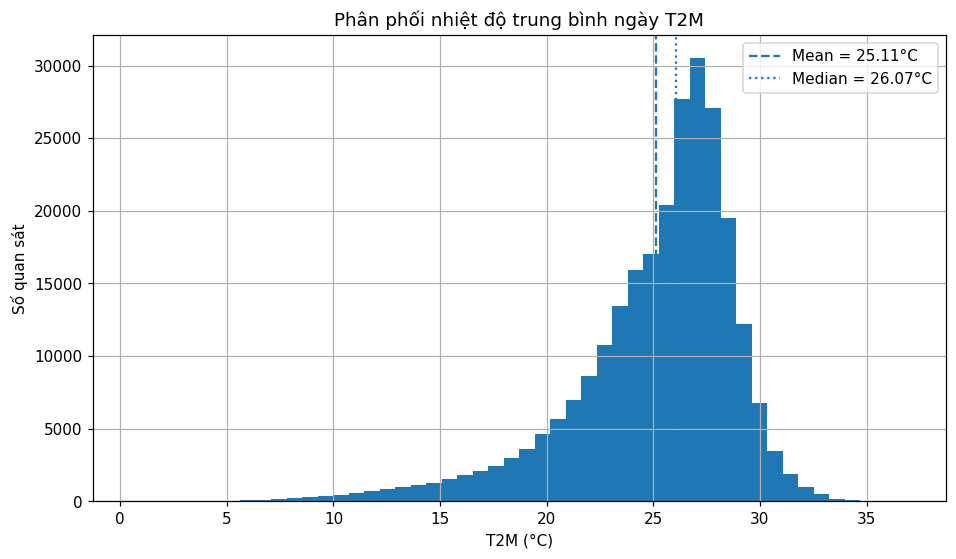

In [ ]:
plt.figure()
plt.hist(df["T2M"].dropna(), bins=50)
plt.axvline(df["T2M"].mean(), linestyle="--", label=f"Mean = {df['T2M'].mean():.2f}°C")
plt.axvline(df["T2M"].median(), linestyle=":", label=f"Median = {df['T2M'].median():.2f}°C")
plt.title("Phân phối nhiệt độ trung bình ngày T2M")
plt.xlabel("T2M (°C)")
plt.ylabel("Số quan sát")
plt.legend()
plt.show()

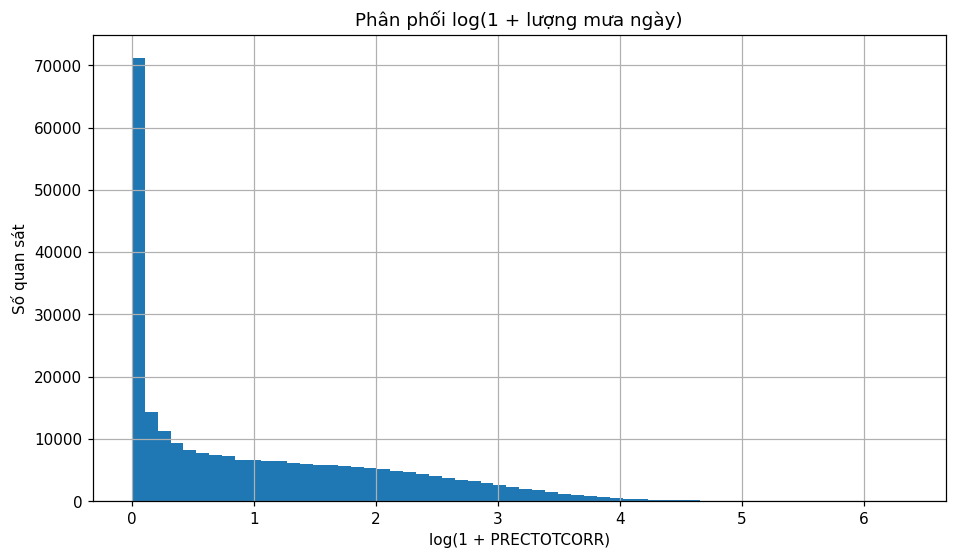

Các phân vị lượng mưa (mm/ngày):


,PRECTOTCORR
0.000,0.000
0.250,0.070
0.500,1.040
0.750,4.990
0.900,13.180
0.950,21.360
0.990,48.180
0.999,115.090
1.000,574.070


In [ ]:
# Lượng mưa lệch phải mạnh, dùng log1p để vẫn giữ được các ngày mưa = 0.
plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=60)
plt.title("Phân phối log(1 + lượng mưa ngày)")
plt.xlabel("log(1 + PRECTOTCORR)")
plt.ylabel("Số quan sát")
plt.show()

print("Các phân vị lượng mưa (mm/ngày):")
display(df["PRECTOTCORR"].quantile([0, .25, .5, .75, .9, .95, .99, .999, 1]).to_frame("PRECTOTCORR"))

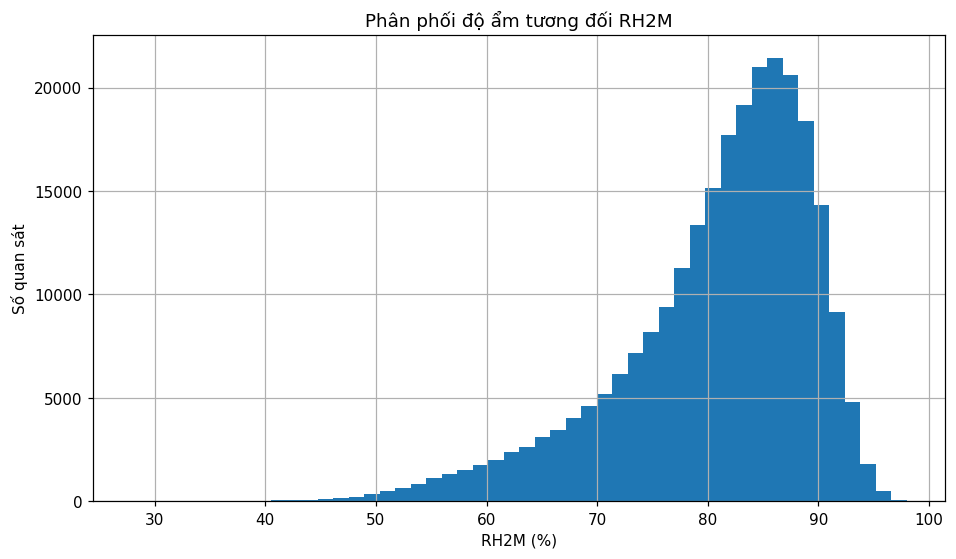

In [ ]:
plt.figure()
plt.hist(df["RH2M"].dropna(), bins=50)
plt.title("Phân phối độ ẩm tương đối RH2M")
plt.xlabel("RH2M (%)")
plt.ylabel("Số quan sát")
plt.show()

## 8. Mùa vụ theo tháng

In [ ]:
monthly = (
    df.groupby(["month", "month_name"], observed=True, as_index=False)
      .agg(
          T2M_mean=("T2M", "mean"),
          T2M_MAX_mean=("T2M_MAX", "mean"),
          precipitation_daily_mean=("PRECTOTCORR", "mean"),
          RH2M_mean=("RH2M", "mean"),
          hot_day_rate=("hot_day", "mean"),
          heavy_rain_day_rate=("heavy_rain_day", "mean"),
      )
      .sort_values("month")
)
monthly["hot_day_rate_pct"] = monthly["hot_day_rate"] * 100
monthly["heavy_rain_day_rate_pct"] = monthly["heavy_rain_day_rate"] * 100
display(monthly)

,month,month_name,T2M_mean,T2M_MAX_mean,precipitation_daily_mean,RH2M_mean,hot_day_rate,heavy_rain_day_rate,hot_day_rate_pct,heavy_rain_day_rate_pct
0,1,Jan,21.347,25.717,1.102,79.778,0.019,0.000,1.894,0.028
1,2,Feb,22.744,27.771,0.700,76.574,0.098,0.000,9.783,0.025
2,3,Mar,24.924,30.161,1.135,74.544,0.177,0.001,17.673,0.097
3,4,Apr,26.934,31.814,2.123,74.230,0.227,0.001,22.738,0.114
4,5,May,27.579,31.418,4.918,78.654,0.117,0.004,11.710,0.406
5,6,Jun,27.352,30.536,6.025,82.114,0.029,0.008,2.857,0.800
6,7,Jul,27.000,30.061,6.816,83.131,0.021,0.010,2.078,0.982
7,8,Aug,26.844,29.879,7.171,83.744,0.008,0.012,0.783,1.249
8,9,Sep,26.257,29.200,9.199,84.840,0.002,0.021,0.229,2.114
9,10,Oct,25.033,28.095,9.390,85.107,0.001,0.029,0.069,2.917


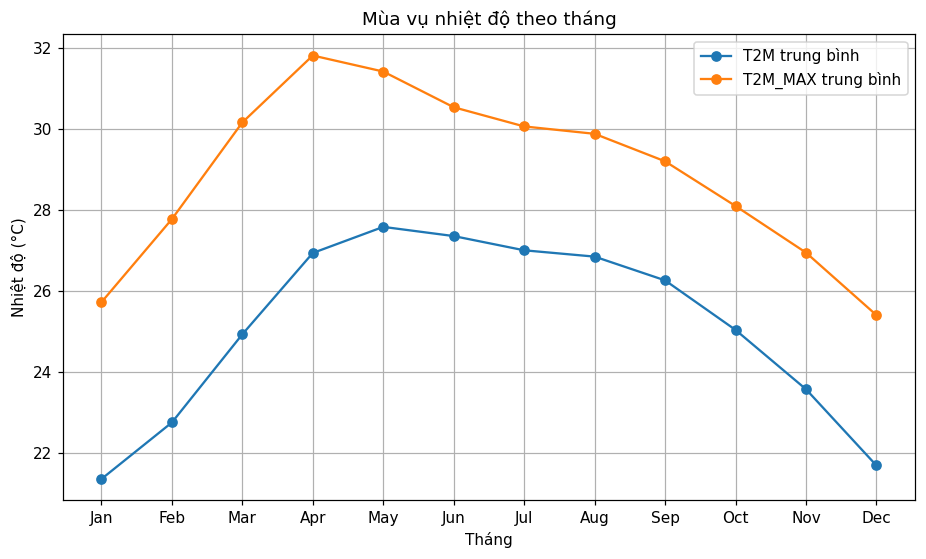

In [ ]:
plt.figure()
plt.plot(monthly["month_name"].astype(str), monthly["T2M_mean"], marker="o", label="T2M trung bình")
plt.plot(monthly["month_name"].astype(str), monthly["T2M_MAX_mean"], marker="o", label="T2M_MAX trung bình")
plt.title("Mùa vụ nhiệt độ theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ (°C)")
plt.legend()
plt.show()

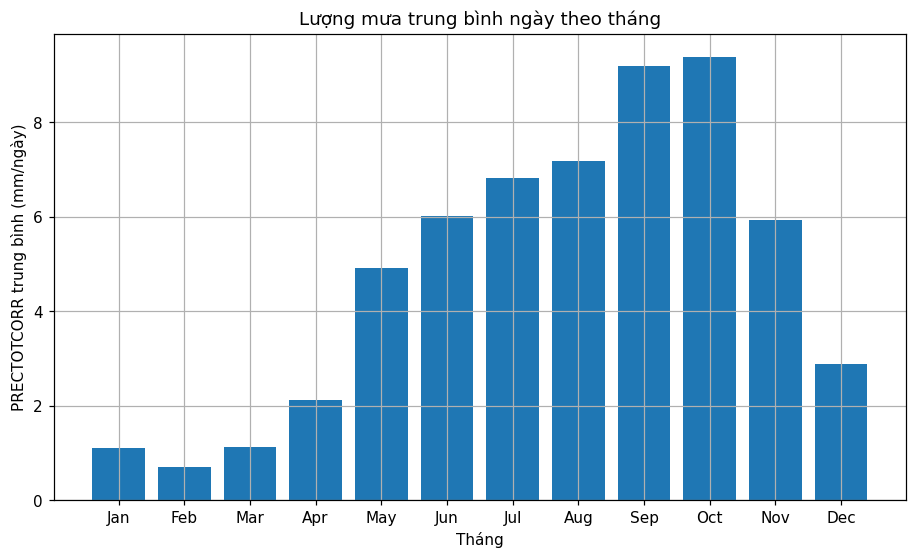

In [ ]:
plt.figure()
plt.bar(monthly["month_name"].astype(str), monthly["precipitation_daily_mean"])
plt.title("Lượng mưa trung bình ngày theo tháng")
plt.xlabel("Tháng")
plt.ylabel("PRECTOTCORR trung bình (mm/ngày)")
plt.show()

## 9. Xu hướng dài hạn theo năm

In [ ]:
# Tổng hợp từng địa điểm trước, sau đó mới lấy trung bình giữa các địa điểm.
# Cách này tránh việc một địa điểm có nhiều dòng hơn làm thay đổi trọng số.
annual_location = (
    df.groupby(["location_id", "location_name", "region", "year"], observed=True, as_index=False)
      .agg(
          observation_days=("date", "size"),
          T2M_mean=("T2M", "mean"),
          precipitation_sum=("PRECTOTCORR", "sum"),
          hot_days=("hot_day", "sum"),
          very_hot_days=("very_hot_day", "sum"),
          heavy_rain_days=("heavy_rain_day", "sum"),
          heatwave_days=("heatwave_day", "sum"),
          heatwave_events=("heatwave_event_start", "sum"),
      )
)

annual_vietnam_points = (
    annual_location.groupby("year", as_index=False)
                   .agg(
                       T2M_mean=("T2M_mean", "mean"),
                       precipitation_mean_per_location=("precipitation_sum", "mean"),
                       hot_days_mean_per_location=("hot_days", "mean"),
                       very_hot_days_mean_per_location=("very_hot_days", "mean"),
                       heavy_rain_days_mean_per_location=("heavy_rain_days", "mean"),
                       heatwave_days_mean_per_location=("heatwave_days", "mean"),
                       heatwave_events_mean_per_location=("heatwave_events", "mean"),
                   )
)
display(annual_vietnam_points.head())

,year,T2M_mean,precipitation_mean_per_location,hot_days_mean_per_location,very_hot_days_mean_per_location,heavy_rain_days_mean_per_location,heatwave_days_mean_per_location,heatwave_events_mean_per_location
0,1991,25.157,"1,476.195",28.800,13.400,2.150,24.150,2.650
1,1992,24.834,"1,602.607",24.150,11.150,3.500,18.550,1.950
2,1993,24.826,"1,607.745",22.800,10.200,2.750,19.300,2.300
3,1994,24.930,"1,712.019",19.900,10.250,2.900,17.000,1.800
4,1995,24.675,"1,762.499",21.300,10.950,2.950,18.800,1.850


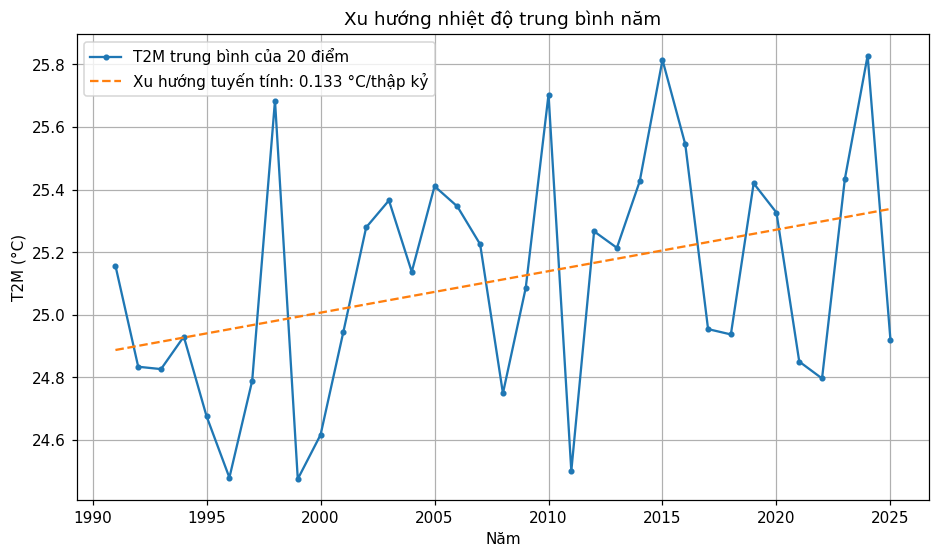

In [ ]:
years = annual_vietnam_points["year"].astype(float).to_numpy()
temps = annual_vietnam_points["T2M_mean"].to_numpy()
slope, intercept = np.polyfit(years, temps, 1)
trend = slope * years + intercept

plt.figure()
plt.plot(years, temps, marker="o", markersize=3, label="T2M trung bình của 20 điểm")
plt.plot(years, trend, linestyle="--", label=f"Xu hướng tuyến tính: {slope * 10:.3f} °C/thập kỷ")
plt.title("Xu hướng nhiệt độ trung bình năm")
plt.xlabel("Năm")
plt.ylabel("T2M (°C)")
plt.legend()
plt.show()

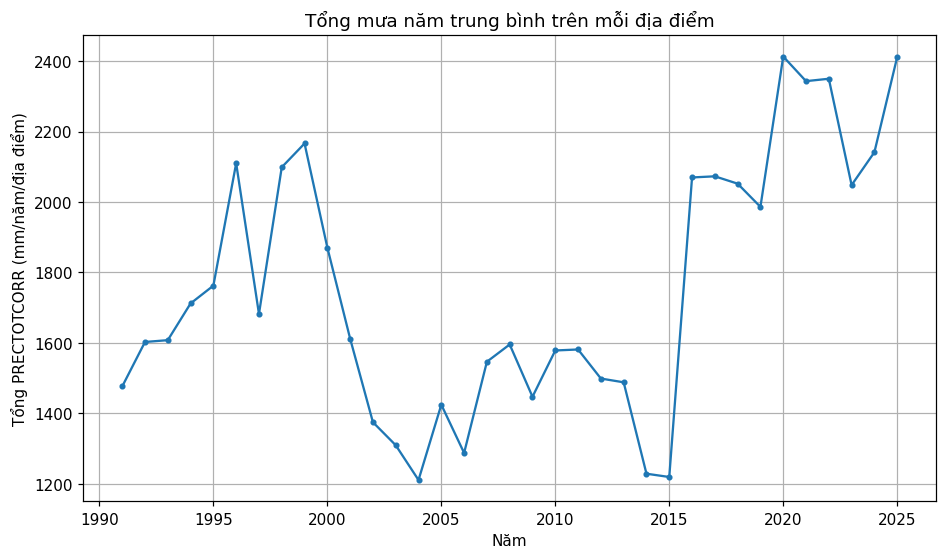

In [ ]:
plt.figure()
plt.plot(
    annual_vietnam_points["year"],
    annual_vietnam_points["precipitation_mean_per_location"],
    marker="o", markersize=3
)
plt.title("Tổng mưa năm trung bình trên mỗi địa điểm")
plt.xlabel("Năm")
plt.ylabel("Tổng PRECTOTCORR (mm/năm/địa điểm)")
plt.show()

## 10. So sánh giữa các vùng

In [ ]:
# Với mưa năm, tổng hợp location-year trước rồi lấy trung bình vùng để tránh cộng lặp số năm/địa điểm.
# Mỗi điểm có cùng độ phủ thời gian, vì vậy các trung bình dưới đây cho trọng số bằng nhau cho từng điểm.
region_daily = (
    df.groupby("region", observed=True)
      .agg(
          n_locations=("location_name", "nunique"),
          T2M_mean=("T2M", "mean"),
          T2M_MAX_mean=("T2M_MAX", "mean"),
          RH2M_mean=("RH2M", "mean"),
          precipitation_daily_mean=("PRECTOTCORR", "mean"),
          hot_day_rate=("hot_day", "mean"),
          heavy_rain_day_rate=("heavy_rain_day", "mean"),
          heatwave_day_rate=("heatwave_day", "mean"),
      )
)
region_annual_rain = (
    annual_location.groupby("region", observed=True)["precipitation_sum"]
                   .mean()
                   .rename("precipitation_annual_mean_per_location")
)
region_summary = region_daily.join(region_annual_rain)
region_summary["hot_day_rate_pct"] = region_summary["hot_day_rate"] * 100
region_summary["heavy_rain_day_rate_pct"] = region_summary["heavy_rain_day_rate"] * 100
region_summary["heatwave_day_rate_pct"] = region_summary["heatwave_day_rate"] * 100
region_summary = region_summary.sort_values("T2M_mean", ascending=False)
display(region_summary)

,n_locations,T2M_mean,T2M_MAX_mean,RH2M_mean,precipitation_daily_mean,hot_day_rate,heavy_rain_day_rate,heatwave_day_rate,precipitation_annual_mean_per_location,hot_day_rate_pct,heavy_rain_day_rate_pct,heatwave_day_rate_pct
region,,,,,,,,,,,,
Đồng bằng sông Cửu Long,4,27.520,30.944,79.770,5.469,0.115,0.007,0.103,"1,997.415",11.544,0.665,10.298
Đông Nam Bộ,2,27.345,31.676,78.917,4.230,0.154,0.003,0.135,"1,545.031",15.426,0.250,13.533
Bắc Trung Bộ,3,25.189,28.166,82.693,5.724,0.053,0.020,0.040,"2,090.867",5.306,1.958,4.028
Nam Trung Bộ,7,24.930,28.528,81.378,4.476,0.023,0.010,0.015,"1,634.925",2.281,1.008,1.494
Đồng bằng sông Hồng,2,23.325,27.460,81.931,4.501,0.026,0.007,0.017,"1,644.164",2.628,0.743,1.651
Trung du và miền núi phía Bắc,2,20.380,26.046,78.957,4.092,0.009,0.004,0.005,"1,494.613",0.903,0.383,0.505


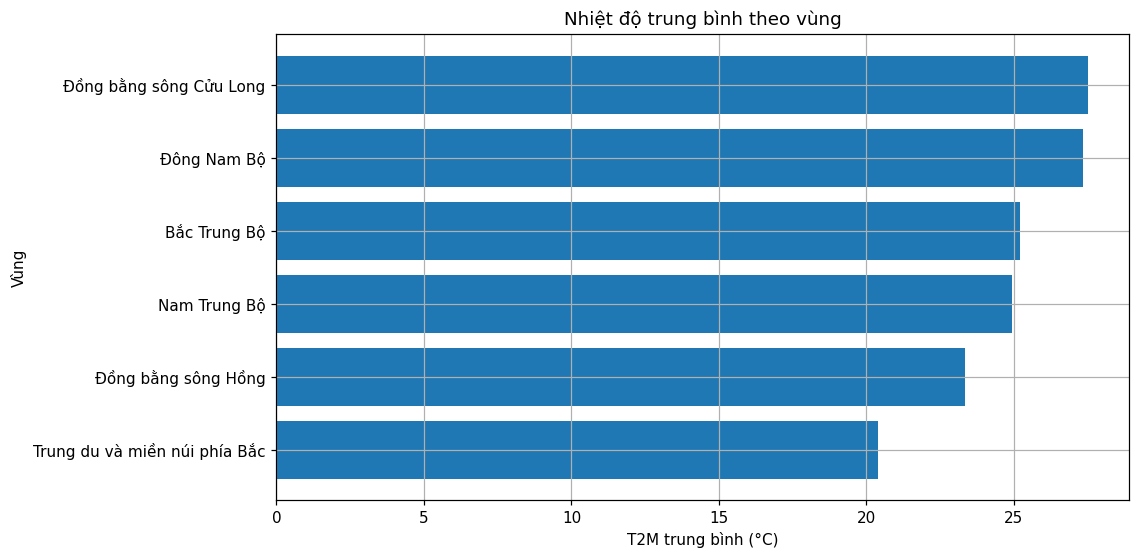

In [ ]:
plot_region = region_summary.sort_values("T2M_mean")
plt.figure()
plt.barh(plot_region.index.astype(str), plot_region["T2M_mean"])
plt.title("Nhiệt độ trung bình theo vùng")
plt.xlabel("T2M trung bình (°C)")
plt.ylabel("Vùng")
plt.show()

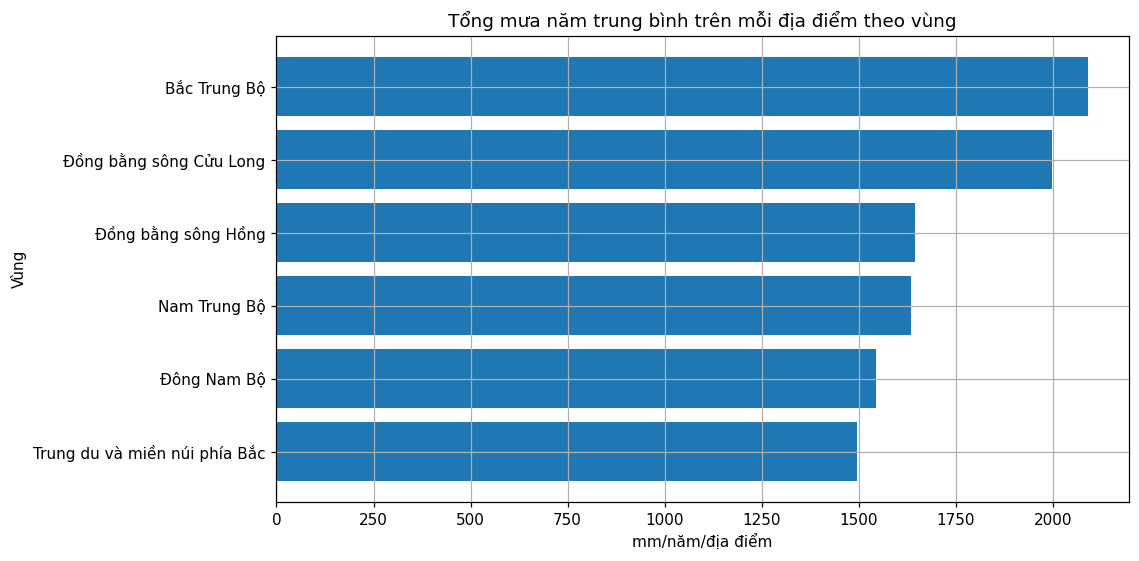

In [ ]:
plot_region = region_summary.sort_values("precipitation_annual_mean_per_location")
plt.figure()
plt.barh(
    plot_region.index.astype(str),
    plot_region["precipitation_annual_mean_per_location"]
)
plt.title("Tổng mưa năm trung bình trên mỗi địa điểm theo vùng")
plt.xlabel("mm/năm/địa điểm")
plt.ylabel("Vùng")
plt.show()

### Nhận xét sau khi chia lại thành 6 nhóm vùng

- **Đồng bằng sông Cửu Long** có nhiệt độ trung bình cao nhất, khoảng **27,52°C**.
- **Đông Nam Bộ** có tỷ lệ ngày nóng và ngày thuộc heatwave cao nhất, lần lượt khoảng **15,43%** và **13,53%** số ngày quan sát.
- **Bắc Trung Bộ** có tổng lượng mưa năm trung bình trên mỗi điểm cao nhất, khoảng **2.090,87 mm/năm/điểm**; đồng thời có độ ẩm trung bình cao nhất (**82,69%**) và tỷ lệ ngày mưa lớn cao nhất (**1,96%**).
- **Trung du và miền núi phía Bắc** có nhiệt độ trung bình thấp nhất, khoảng **20,38°C**, và tổng lượng mưa năm trung bình trên mỗi điểm thấp nhất, khoảng **1.494,61 mm/năm/điểm**.
- Nhóm **Nam Trung Bộ** trong notebook gồm **7 điểm**, bao gồm cả các điểm ven biển và Tây Nguyên. Vì vậy, giá trị trung bình của nhóm có thể che khuất khác biệt nội vùng; khi diễn giải nên xem thêm kết quả ở cấp điểm tham chiếu.

## 11. Tương quan giữa các biến khí hậu

,T2M,T2M_MAX,T2M_MIN,T2MDEW,RH2M,QV2M,PRECTOTCORR,WS10M,PS,ALLSKY_SFC_SW_DWN,temperature_range
T2M,1.000,0.870,0.936,0.840,-0.186,0.809,0.063,0.134,0.402,0.508,-0.178
T2M_MAX,0.870,1.000,0.650,0.533,-0.497,0.506,-0.084,-0.079,0.161,0.602,0.325
T2M_MIN,0.936,0.650,1.000,0.930,0.072,0.897,0.152,0.269,0.501,0.363,-0.507
T2MDEW,0.840,0.533,0.930,1.000,0.371,0.982,0.224,0.180,0.434,0.265,-0.552
RH2M,-0.186,-0.497,0.072,0.371,1.000,0.393,0.321,0.071,0.068,-0.396,-0.653
QV2M,0.809,0.506,0.897,0.982,0.393,1.000,0.253,0.107,0.327,0.268,-0.542
PRECTOTCORR,0.063,-0.084,0.152,0.224,0.321,0.253,1.000,0.157,0.026,-0.313,-0.284
WS10M,0.134,-0.079,0.269,0.180,0.071,0.107,0.157,1.000,0.548,-0.183,-0.424
PS,0.402,0.161,0.501,0.434,0.068,0.327,0.026,0.548,1.000,0.017,-0.440
ALLSKY_SFC_SW_DWN,0.508,0.602,0.363,0.265,-0.396,0.268,-0.313,-0.183,0.017,1.000,0.230


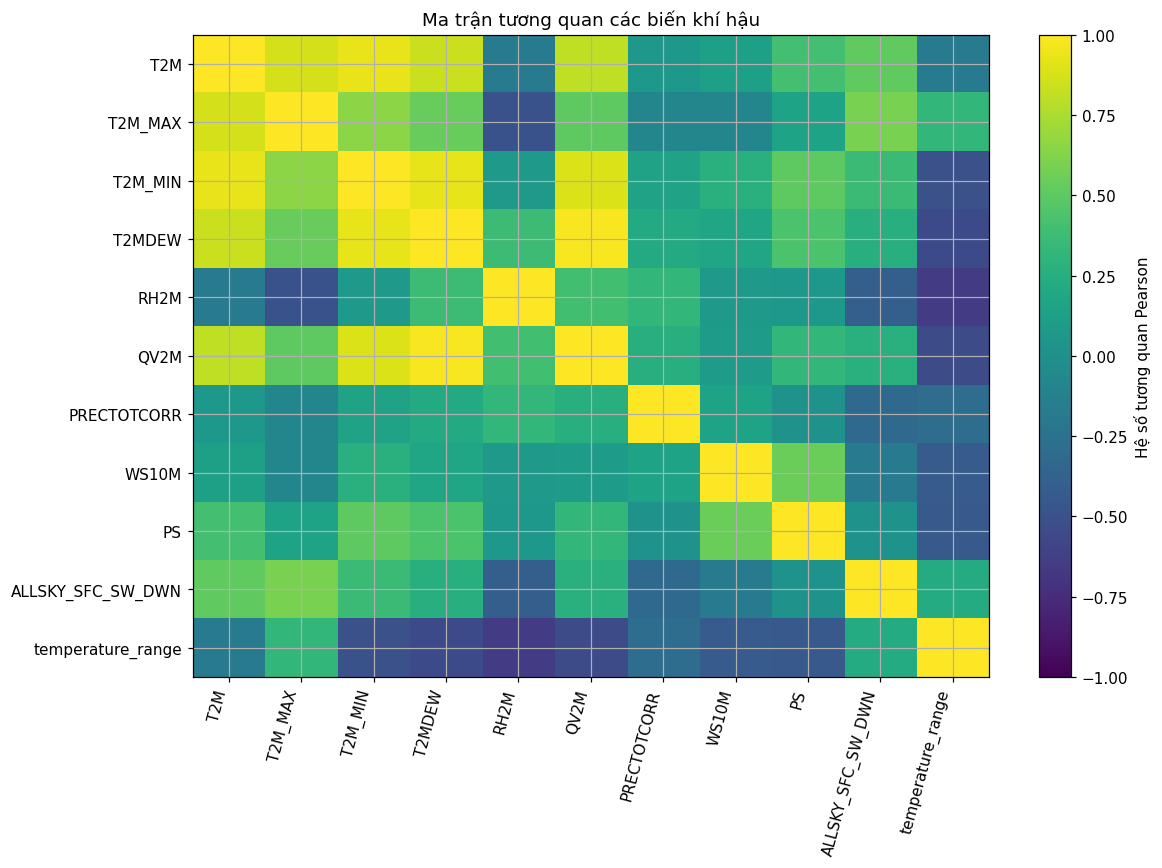

In [ ]:
corr_cols = [
    "T2M", "T2M_MAX", "T2M_MIN", "T2MDEW", "RH2M", "QV2M",
    "PRECTOTCORR", "WS10M", "PS", "ALLSKY_SFC_SW_DWN", "temperature_range"
]
corr = df[corr_cols].corr()
display(corr.round(3))

plt.figure(figsize=(11, 8))
img = plt.imshow(corr, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(img, label="Hệ số tương quan Pearson")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=75, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Ma trận tương quan các biến khí hậu")
plt.tight_layout()
plt.show()

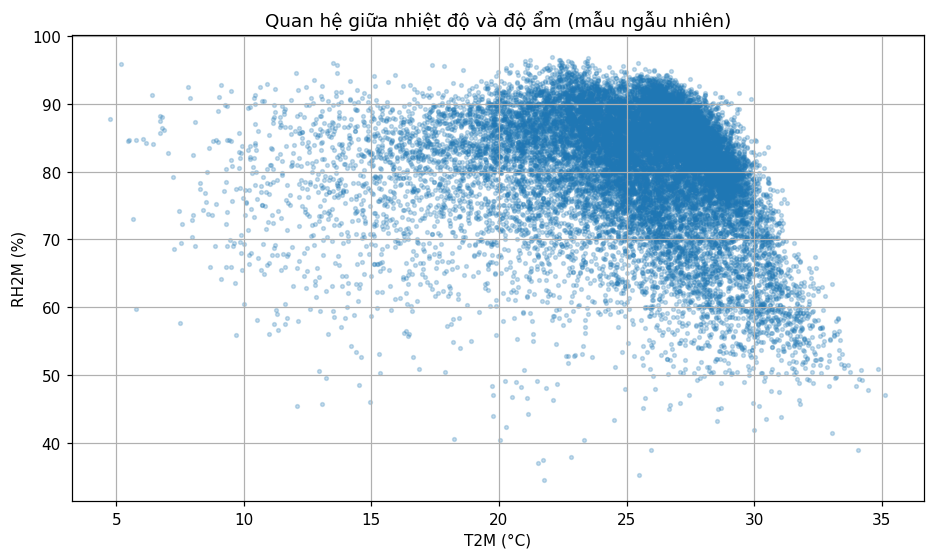

In [ ]:
# Scatter dùng mẫu ngẫu nhiên để biểu đồ nhẹ hơn nhưng vẫn giữ cấu trúc tổng thể.
sample_n = min(20_000, len(df))
scatter_sample = df[["T2M", "RH2M", "PRECTOTCORR"]].sample(sample_n, random_state=42)

plt.figure()
plt.scatter(scatter_sample["T2M"], scatter_sample["RH2M"], s=6, alpha=0.25)
plt.title("Quan hệ giữa nhiệt độ và độ ẩm (mẫu ngẫu nhiên)")
plt.xlabel("T2M (°C)")
plt.ylabel("RH2M (%)")
plt.show()

## 12. EDA các hiện tượng cực đoan

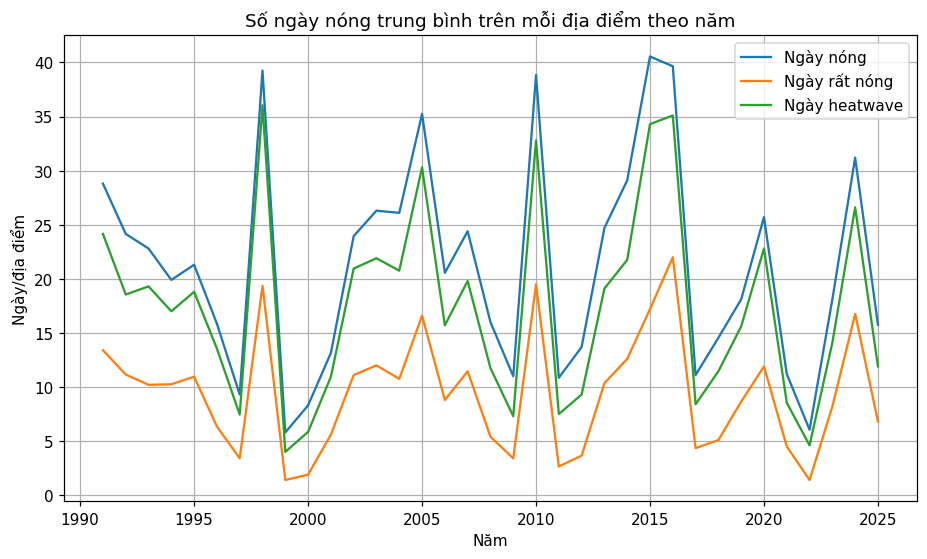

In [ ]:
plt.figure()
plt.plot(
    annual_vietnam_points["year"],
    annual_vietnam_points["hot_days_mean_per_location"],
    label="Ngày nóng"
)
plt.plot(
    annual_vietnam_points["year"],
    annual_vietnam_points["very_hot_days_mean_per_location"],
    label="Ngày rất nóng"
)
plt.plot(
    annual_vietnam_points["year"],
    annual_vietnam_points["heatwave_days_mean_per_location"],
    label="Ngày heatwave"
)
plt.title("Số ngày nóng trung bình trên mỗi địa điểm theo năm")
plt.xlabel("Năm")
plt.ylabel("Ngày/địa điểm")
plt.legend()
plt.show()

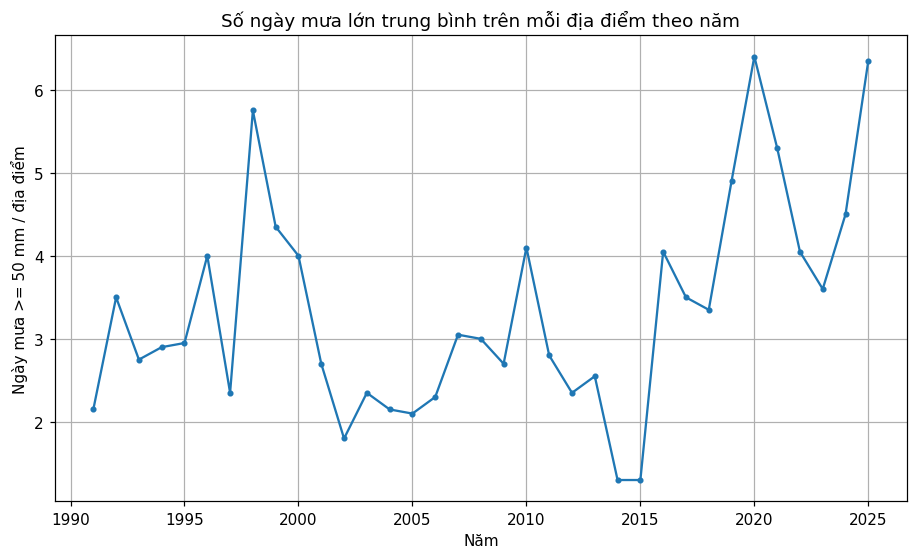

In [ ]:
plt.figure()
plt.plot(
    annual_vietnam_points["year"],
    annual_vietnam_points["heavy_rain_days_mean_per_location"],
    marker="o", markersize=3
)
plt.title("Số ngày mưa lớn trung bình trên mỗi địa điểm theo năm")
plt.xlabel("Năm")
plt.ylabel("Ngày mưa >= 50 mm / địa điểm")
plt.show()

## 13. Phân tích heatwave ở cấp độ sự kiện

In [ ]:
heatwave_rows = df[df["heatwave_day"] == 1].copy()

heatwave_events = (
    heatwave_rows.groupby("heatwave_event_id", observed=True, as_index=False)
                 .agg(
                     location_id=("location_id", "first"),
                     location_name=("location_name", "first"),
                     region=("region", "first"),
                     event_start_date=("date", "min"),
                     event_end_date=("date", "max"),
                     event_length=("heatwave_event_length", "max"),
                     row_count=("date", "size"),
                     maximum_T2M_MAX=("T2M_MAX", "max"),
                     mean_T2M=("T2M", "mean"),
                     mean_RH2M=("RH2M", "mean"),
                     total_precipitation=("PRECTOTCORR", "sum"),
                     start_flags=("heatwave_event_start", "sum"),
                     end_flags=("heatwave_event_end", "sum"),
                 )
)

heatwave_event_audit = pd.DataFrame({
    "Kiểm tra": [
        "Số events",
        "row_count khác event_length",
        "Event không có đúng 1 start flag",
        "Event không có đúng 1 end flag",
        "Event dài dưới 3 ngày",
    ],
    "Kết quả": [
        len(heatwave_events),
        int((heatwave_events["row_count"] != heatwave_events["event_length"]).sum()),
        int((heatwave_events["start_flags"] != 1).sum()),
        int((heatwave_events["end_flags"] != 1).sum()),
        int((heatwave_events["event_length"] < 3).sum()),
    ]
})
display(heatwave_event_audit)
display(heatwave_events["event_length"].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame())

,Kiểm tra,Kết quả
0,Số events,1368
1,row_count khác event_length,0
2,Event không có đúng 1 start flag,0
3,Event không có đúng 1 end flag,0
4,Event dài dưới 3 ngày,0


,event_length
count,"1,368.000"
mean,8.888
std,12.259
min,3.000
50%,5.000
75%,9.000
90%,18.000
95%,29.650
99%,69.000
max,104.000


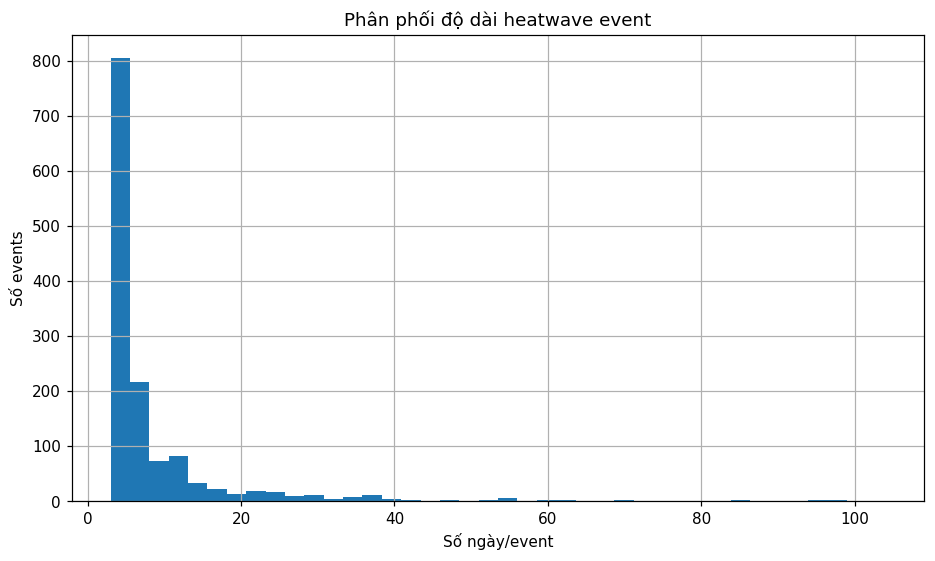

In [ ]:
plt.figure()
plt.hist(heatwave_events["event_length"], bins=40)
plt.title("Phân phối độ dài heatwave event")
plt.xlabel("Số ngày/event")
plt.ylabel("Số events")
plt.show()

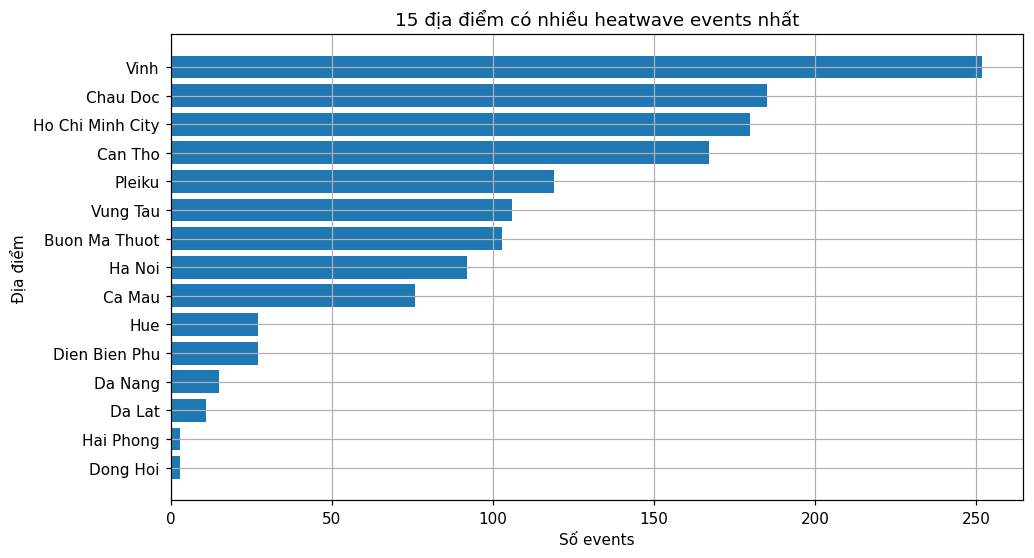

In [ ]:
events_by_location = (
    heatwave_events.groupby("location_name", observed=True)
                   .size()
                   .sort_values(ascending=False)
                   .head(15)
                   .sort_values()
)
plt.figure()
plt.barh(events_by_location.index.astype(str), events_by_location.values)
plt.title("15 địa điểm có nhiều heatwave events nhất")
plt.xlabel("Số events")
plt.ylabel("Địa điểm")
plt.show()

In [ ]:
top_heatwaves = (
    heatwave_events.sort_values(
        ["event_length", "maximum_T2M_MAX"], ascending=[False, False]
    )
    .head(15)
    [[
        "heatwave_event_id", "location_name", "region", "event_start_date",
        "event_end_date", "event_length", "maximum_T2M_MAX", "mean_T2M",
        "mean_RH2M", "total_precipitation"
    ]]
)
display(top_heatwaves)

,heatwave_event_id,location_name,region,event_start_date,event_end_date,event_length,maximum_T2M_MAX,mean_T2M,mean_RH2M,total_precipitation
765,SGN_20100207,Ho Chi Minh City,Đông Nam Bộ,2010-02-07,2010-05-21,104,41.880,30.723,59.267,38.520
211,CDO_19980115,Chau Doc,Đồng bằng sông Cửu Long,1998-01-15,1998-04-25,101,42.230,31.102,55.448,13.110
801,SGN_20160209,Ho Chi Minh City,Đông Nam Bộ,2016-02-09,2016-05-16,98,41.830,31.106,55.333,12.940
967,VCA_20160209,Can Tho,Đồng bằng sông Cửu Long,2016-02-09,2016-05-15,97,42.000,30.987,57.326,25.950
874,VCA_19980208,Can Tho,Đồng bằng sông Cửu Long,1998-02-08,1998-05-14,96,41.990,31.283,56.554,23.740
794,SGN_20150201,Ho Chi Minh City,Đông Nam Bộ,2015-02-01,2015-05-06,95,41.210,30.056,55.333,7.870
705,SGN_19980116,Ho Chi Minh City,Đông Nam Bộ,1998-01-16,1998-04-17,92,41.970,29.930,57.522,3.300
963,VCA_20150220,Can Tho,Đồng bằng sông Cửu Long,2015-02-20,2015-05-21,91,40.930,30.785,58.745,45.490
315,CDO_20160209,Chau Doc,Đồng bằng sông Cửu Long,2016-02-09,2016-05-05,87,41.250,31.608,53.604,5.260
998,VCA_20240209,Can Tho,Đồng bằng sông Cửu Long,2024-02-09,2024-05-04,86,43.710,31.179,59.592,15.360


## 14. Kiểm tra các giá trị cực trị đáng chú ý

In [ ]:
max_temp_rows = df.nlargest(10, "T2M_MAX")[[
    "date", "location_name", "region", "T2M", "T2M_MAX", "T2M_MIN", "RH2M"
]]
max_rain_rows = df.nlargest(10, "PRECTOTCORR")[[
    "date", "location_name", "region", "PRECTOTCORR", "T2M", "RH2M", "WS10M"
]]

print("10 quan sát có T2M_MAX cao nhất:")
display(max_temp_rows)
print("10 quan sát có lượng mưa ngày cao nhất:")
display(max_rain_rows)

10 quan sát có T2M_MAX cao nhất:


,date,location_name,region,T2M,T2M_MAX,T2M_MIN,RH2M
90706,1994-05-03,Ha Noi,Đồng bằng sông Hồng,36.280,45.470,26.830,49.110
90705,1994-05-02,Ha Noi,Đồng bằng sông Hồng,36.890,45.410,29.950,36.440
234621,2003-05-07,Vinh,Bắc Trung Bộ,35.700,44.390,28.540,45.500
216716,2024-04-29,Can Tho,Đồng bằng sông Cửu Long,35.110,43.710,28.070,45.950
37740,2024-04-29,Chau Doc,Đồng bằng sông Cửu Long,35.760,43.550,29.490,46.140
237191,2010-05-20,Vinh,Bắc Trung Bộ,36.330,43.510,30.050,42.930
237153,2010-04-12,Vinh,Bắc Trung Bộ,34.740,43.460,28.290,35.820
216714,2024-04-27,Can Tho,Đồng bằng sông Cửu Long,34.980,43.440,28.540,49.930
90704,1994-05-01,Ha Noi,Đồng bằng sông Hồng,34.770,43.360,28.480,45.960
238986,2015-04-19,Vinh,Bắc Trung Bộ,34.520,43.230,27.640,39.580


10 quan sát có lượng mưa ngày cao nhất:


,date,location_name,region,PRECTOTCORR,T2M,RH2M,WS10M
215301,2020-06-14,Can Tho,Đồng bằng sông Cửu Long,574.070,27.350,92.660,3.520
36325,2020-06-14,Chau Doc,Đồng bằng sông Cửu Long,531.770,27.500,93.200,3.870
62745,2022-10-14,Da Nang,Nam Trung Bộ,389.240,25.200,94.970,6.560
126665,2022-10-14,Hue,Bắc Trung Bộ,346.020,24.550,93.410,7.890
240995,2020-10-18,Vinh,Bắc Trung Bộ,338.190,21.740,94.960,9.260
239530,2016-10-14,Vinh,Bắc Trung Bộ,317.340,24.850,95.350,7.510
242767,2025-08-25,Vinh,Bắc Trung Bộ,306.390,26.250,92.850,8.420
62347,2021-09-11,Da Nang,Nam Trung Bộ,304.870,26.930,91.330,7.710
63717,2025-06-12,Da Nang,Nam Trung Bộ,296.790,26.020,86.860,7.260
226745,2016-10-13,Dong Hoi,Bắc Trung Bộ,276.100,27.200,88.350,8.360


## 15. Xuất dữ liệu đã làm sạch

In [ ]:
# Đổi thành True khi muốn ghi thêm file clean CSV.
SAVE_CLEAN_DATA = False

if SAVE_CLEAN_DATA:
    output_path = Path("/content/nasa_power_vietnam_daily_clean.csv")
    if not output_path.parent.exists():
        output_path = Path.cwd() / "nasa_power_vietnam_daily_clean.csv"
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print("Đã lưu:", output_path)
else:
    print("SAVE_CLEAN_DATA = False: chưa ghi file CSV để tránh tạo thêm file khoảng hàng chục MB.")

SAVE_CLEAN_DATA = False: chưa ghi file CSV để tránh tạo thêm file khoảng hàng chục MB.


## Kết luận chung

Qua quá trình thống kê tổng quan, kiểm tra chất lượng, tiền xử lý và phân tích khám phá, bộ dữ liệu NASA POWER Việt Nam có thể được xem là **đủ đầy đủ và nhất quán để tiếp tục sử dụng cho các phân tích khí hậu và mô hình hóa chuỗi thời gian**. Dữ liệu gồm **255.680 location-days**, tương ứng với **20 điểm tham chiếu thuộc 6 nhóm vùng phân tích**, kéo dài liên tục trong **35 năm, từ 01/01/1991 đến 31/12/2025**.

### 1. Chất lượng và tiền xử lý dữ liệu

Các biến khí tượng cốt lõi như nhiệt độ, lượng mưa, độ ẩm, gió, áp suất và bức xạ không bị thiếu. Khóa kết hợp `date + location_id` là duy nhất sau bước kiểm tra và loại trùng, bảo đảm mỗi dòng đại diện cho đúng **một địa điểm trong một ngày**.

Giá trị thiếu chủ yếu xuất hiện ở ba cột và đều có nguyên nhân hợp lý:

- `heatwave_event_id` thiếu ở những ngày không thuộc sự kiện heatwave.
- `T2M_7d_rolling_mean` thiếu tại những ngày đầu chuỗi vì chưa đủ 7 ngày quan sát.
- `T2M_30d_rolling_mean` thiếu tại những ngày đầu chuỗi vì chưa đủ 30 ngày quan sát.

Đây là các giá trị thiếu mang tính **cấu trúc**, không phải dữ liệu khí tượng bị mất. Vì vậy, không nên tự động điền trung bình hoặc mode cho các trường hợp này. Các cờ thời tiết cực đoan cũng được kiểm tra và nhất quán với ngưỡng đã định nghĩa.

### 2. Đặc điểm nhiệt độ, lượng mưa và sự khác biệt giữa 6 vùng

Kết quả EDA cho thấy nhiệt độ trung bình của 20 điểm quan sát có xu hướng tăng khoảng **0,133°C mỗi thập kỷ**. Trung bình nhiệt độ của 5 năm cuối cao hơn 5 năm đầu khoảng **0,281°C**. Đây là dấu hiệu mô tả cho thấy nền nhiệt tại các điểm khảo sát đã tăng trong giai đoạn nghiên cứu; kết quả chưa đủ để khẳng định quan hệ nhân quả.

Theo mùa vụ, **tháng 5** có nhiệt độ trung bình cao nhất, khoảng **27,58°C**, trong khi **tháng 10** có lượng mưa trung bình ngày cao nhất, khoảng **9,39 mm/ngày**. Sự khác biệt rõ rệt giữa các tháng phản ánh tính mùa vụ mạnh của khí hậu tại tập điểm nghiên cứu.

Sau khi chia lại thành 6 nhóm vùng:

- **Đồng bằng sông Cửu Long** có nhiệt độ trung bình cao nhất, khoảng **27,52°C**.
- **Đông Nam Bộ** có tỷ lệ ngày nóng cao nhất, khoảng **15,43%**, và tỷ lệ ngày thuộc heatwave cao nhất, khoảng **13,53%**.
- **Bắc Trung Bộ** có tổng lượng mưa năm trung bình trên mỗi điểm cao nhất, khoảng **2.090,87 mm/năm/điểm**; đồng thời có độ ẩm trung bình cao nhất, khoảng **82,69%**, và tỷ lệ ngày mưa lớn cao nhất, khoảng **1,96%**.
- **Trung du và miền núi phía Bắc** có nhiệt độ trung bình thấp nhất, khoảng **20,38°C**, và tổng lượng mưa năm trung bình trên mỗi điểm thấp nhất, khoảng **1.494,61 mm/năm/điểm**.

Các kết quả này cho thấy đặc điểm khí hậu phân hóa rõ giữa các nhóm vùng và không nên chỉ dùng một giá trị trung bình chung để đại diện cho toàn bộ Việt Nam.

### 3. Các hiện tượng thời tiết cực đoan

Trong toàn bộ dữ liệu:

- Có **14.826 ngày nóng**, tương đương **5,799%** tổng số location-days.
- Có **6.581 ngày rất nóng**, tương đương **2,574%**.
- Có **2.345 ngày mưa lớn**, tương đương **0,917%**.
- Có **126.245 ngày khô**, tương đương **49,376%**.
- Có **12.159 ngày thuộc heatwave**, tương đương **4,756%**.

Ngày khô xuất hiện phổ biến nhất, nhưng chỉ tiêu này chỉ phản ánh lượng mưa dưới 1 mm trong một ngày và **không đồng nghĩa trực tiếp với hạn hán**. Để đánh giá hạn hán cần xem xét chuỗi thời gian dài hơn, tổng lượng mưa tích lũy và các chỉ số chuyên biệt.

Nhiệt độ cực đại lớn nhất trong dữ liệu là **45,47°C tại Hà Nội ngày 03/05/1994**. Lượng mưa ngày lớn nhất là **574,07 mm tại Cần Thơ ngày 14/06/2020**. Đây là các giá trị cực trị đáng chú ý và nên được đối chiếu thêm với nguồn quan trắc khác trước khi sử dụng trong các kết luận chuyên sâu.

### 4. Đặc điểm của các sự kiện heatwave

Dữ liệu ghi nhận **1.368 sự kiện heatwave**. Độ dài trung vị là **5 ngày**, trong khi độ dài trung bình khoảng **8,89 ngày**. Phân phối độ dài lệch phải rõ rệt: phần lớn sự kiện kéo dài trong thời gian ngắn, nhưng vẫn tồn tại một số ít sự kiện rất dài làm tăng giá trị trung bình.

Sự kiện dài nhất được ghi nhận tại **Thành phố Hồ Chí Minh**, từ **07/02/2010 đến 21/05/2010**, kéo dài **104 ngày**.

### 5. Hạn chế khi diễn giải kết quả

Các địa điểm trong dữ liệu là những điểm hoặc grid tham chiếu. Vì vậy, trung bình của 20 địa điểm là **trung bình trên tập điểm khảo sát**, không phải trung bình có trọng số theo diện tích của toàn Việt Nam, từng vùng hoặc từng tỉnh.

Số điểm giữa các nhóm không bằng nhau: nhóm Nam Trung Bộ có 7 điểm, Đồng bằng sông Cửu Long có 4 điểm, Bắc Trung Bộ có 3 điểm, còn ba nhóm khác có 2 điểm. Đặc biệt, nhóm **Nam Trung Bộ** theo cách phân nhóm của notebook bao gồm cả các điểm ven biển và Tây Nguyên, nên trung bình vùng có thể che khuất sự khác biệt nội vùng.

NASA POWER là nguồn dữ liệu lưới, nên giá trị tại một điểm không nhất thiết giống hoàn toàn với số liệu của trạm quan trắc mặt đất. Các giá trị cực trị và những sự kiện bất thường cần được kiểm chứng thêm trước khi sử dụng cho cảnh báo, thiết kế hạ tầng hoặc ra quyết định chính sách.

Ngoài ra, EDA chủ yếu cho biết mô hình, xu hướng và sự liên hệ trong dữ liệu. Các kết quả tương quan hoặc xu hướng quan sát được không tự động chứng minh nguyên nhân.

### 6. Kết luận cuối cùng

Nhìn chung, bộ dữ liệu có chất lượng tốt, phạm vi thời gian dài và cấu trúc phù hợp để nghiên cứu nhiệt độ, lượng mưa, tính mùa vụ và các hiện tượng cực đoan tại nhiều địa điểm ở Việt Nam. Phân tích ban đầu cho thấy nền nhiệt có xu hướng tăng, điều kiện khí hậu khác biệt đáng kể giữa 6 nhóm vùng, ngày khô xuất hiện phổ biến và các sự kiện heatwave chủ yếu ngắn nhưng có một số trường hợp kéo dài bất thường.

Bộ dữ liệu sau tiền xử lý có thể tiếp tục được sử dụng cho các hướng như:

- Phân tích xu hướng khí hậu theo từng địa điểm và từng vùng.
- So sánh các giai đoạn khí hậu khác nhau.
- Phát hiện và dự báo heatwave hoặc mưa lớn.
- Xây dựng mô hình chuỗi thời gian với các biến rolling mean và lag.
- Phân tích mối liên hệ giữa nhiệt độ, độ ẩm, mưa, gió và bức xạ.